In [1]:
# Structure
# CELL 1: Install packages
# CELL 2: Import libraries
# CELL 3: All class definitions
# CELL 4: Your API keys
# CELL 5: Run trading (Run daily to rebalance)
# CELL 6: View performance
# CELL 7: Manual commands
# CELL 8; Risk adjusted performance metrics
# CELL 9: 5 year backtest with statistical significance

In [2]:
%pip install --upgrade alpaca-trade-api pandas numpy matplotlib scipy websockets yfinance
print("All required packages are installed.")

Defaulting to user installation because normal site-packages is not writeable


  Using cached websockets-15.0.1-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.8 kB)


  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)


INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
  Using cached yfinance-1.1.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached yfinance-1.0-py2.py3-none-any.whl.metadata (6.0 kB)


  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached yfinance-0.2.65-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached yfinance-0.2.64-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached yfinance-0.2.63-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached yfinance-0.2.62-py2.py3-none-any.whl.metadata (5.8 kB)
INFO: pip is still looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
  Using cached yfinance-0.2.61-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached yfinance-0.2.60-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached yfinance-0.2.59-py2.py3-none-any.whl.metadata (5.7 kB)


  Using cached protobuf-5.29.6-cp38-abi3-macosx_10_9_universal2.whl.metadata (592 bytes)



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
All required packages are installed.


In [3]:
# install alpaca-trade-api yfinance pandas numpy matplotlib

try:
    import alpaca
except ImportError:
    !python3 -m pip install alpaca-py
    import alpaca
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from datetime import datetime, timedelta
import alpaca_trade_api as tradeapi

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


In [4]:
# ALPACA PAPER TRADING ENGINE
# ============================================================================

class AlpacaPaperTrading:
    """Automated paper trading via Alpaca API"""
    
    def __init__(self, api_key=None, secret_key=None):
        """Initialize Alpaca paper trading client"""
        
        self.api_key = api_key or os.getenv('ALPACA_API_KEY')
        self.secret_key = secret_key or os.getenv('ALPACA_SECRET_KEY')
        
        if not self.api_key or not self.secret_key:
            raise ValueError("Alpaca API keys required. Pass them as: AlpacaPaperTrading(api_key='...', secret_key='...')")
        
        # Initialize API client
        self.api = tradeapi.REST(
            key_id=self.api_key,
            secret_key=self.secret_key,
            base_url='https://paper-api.alpaca.markets',  # Paper trading endpoint
            api_version='v2'
        )
        
        print("✓ Connected to Alpaca Paper Trading")
    
    def get_account(self):
        """Get account information"""
        account = self.api.get_account()
        
        print(f"\n{'='*70}")
        print("ALPACA PAPER TRADING ACCOUNT")
        print(f"{'='*70}")
        print(f"Buying Power: ${float(account.buying_power):,.2f}")
        print(f"Cash: ${float(account.cash):,.2f}")
        print(f"Portfolio Value: ${float(account.portfolio_value):,.2f}")
        print(f"Account Status: {account.status}")
        
        return account
    
    def get_positions(self):
        """Get current positions"""
        positions = self.api.list_positions()
        
        if not positions:
            print("\nNo current positions")
            return {}
        
        print(f"\n{'='*70}")
        print("CURRENT POSITIONS")
        print(f"{'='*70}")
        
        positions_dict = {}
        
        for position in positions:
            ticker = position.symbol
            shares = float(position.qty)
            current_price = float(position.current_price)
            market_value = float(position.market_value)
            unrealized_pl = float(position.unrealized_pl)
            unrealized_plpc = float(position.unrealized_plpc)
            
            positions_dict[ticker] = {
                'shares': shares,
                'price': current_price,
                'value': market_value,
                'unrealized_pl': unrealized_pl,
                'unrealized_plpc': unrealized_plpc
            }
            
            print(f"{ticker}: {shares} shares @ ${current_price:.2f} = ${market_value:,.2f} ({unrealized_plpc:+.2%})")
        
        return positions_dict
    
    def place_order(self, ticker, shares, side):
        """Place market order"""
        
        try:
            order = self.api.submit_order(
                symbol=ticker,
                qty=abs(shares),
                side=side.lower(),
                type='market',
                time_in_force='day'
            )
            print(f"✓ {side} order placed: {abs(shares)} shares of {ticker}")
            return order
        except Exception as e:
            print(f"  Order failed for {ticker}: {str(e)}")
            return None
    
    def close_all_positions(self):
        """Close all current positions"""
        print(f"\n{'='*70}")
        print("CLOSING ALL POSITIONS")
        print(f"{'='*70}")
        
        try:
            self.api.close_all_positions()
            print("✓ All positions closed")
        except Exception as e:
            print(f"  Error closing positions: {str(e)}")
    
    def rebalance_to_target(self, target_weights):
        """Rebalance portfolio to target allocation"""
        
        print(f"\n{'='*70}")
        print("REBALANCING TO TARGET ALLOCATION")
        print(f"{'='*70}")
        
        # Get account info
        account = self.api.get_account()
        total_value = float(account.portfolio_value)
        
        print(f"\nTotal Portfolio Value: ${total_value:,.2f}")
        
        # Get current positions
        current_positions = self.get_positions()
        
        # Get current prices
        tickers = list(set(list(target_weights.keys()) + list(current_positions.keys())))
        
        print(f"\nTarget Allocation:")
        for ticker, weight in sorted(target_weights.items(), key=lambda x: x[1], reverse=True):
            target_value = total_value * weight
            print(f"  {ticker}: {weight:.2%} (${target_value:,.2f})")
        
        # Get latest prices
        price_data = yf.download(tickers, period='1d', progress=False)
        
        current_prices = {}
        if len(tickers) == 1:
            current_prices[tickers[0]] = price_data['Close'].iloc[-1]
        else:
            for ticker in tickers:
                try:
                    current_prices[ticker] = price_data['Close'][ticker].iloc[-1]
                except:
                    current_prices[ticker] = 0
        
        # Calculate trades
        trades = []
        
        for ticker, target_weight in target_weights.items():
            target_value = total_value * target_weight
            current_shares = current_positions.get(ticker, {}).get('shares', 0)
            current_price = current_prices.get(ticker, 0)
            
            if current_price == 0:
                print(f"  Skipping {ticker}: No price data")
                continue
            
            target_shares = int(target_value / current_price)
            shares_diff = target_shares - current_shares
            
            if abs(shares_diff) > 0:
                side = 'buy' if shares_diff > 0 else 'sell'
                trades.append({
                    'ticker': ticker,
                    'shares': abs(shares_diff),
                    'side': side,
                    'priority': 0 if side == 'sell' else 1
                })
        
        # Close positions not in target
        for ticker in current_positions.keys():
            if ticker not in target_weights:
                shares = current_positions[ticker]['shares']
                trades.append({
                    'ticker': ticker,
                    'shares': shares,
                    'side': 'sell',
                    'priority': 0
                })
        
        # Execute trades (sells first)
        print(f"\nExecuting Trades:")
        for trade in sorted(trades, key=lambda x: x['priority']):
            self.place_order(
                ticker=trade['ticker'],
                shares=trade['shares'],
                side=trade['side']
            )
        
        print(f"\n✓ Rebalancing complete")
        
        # Wait for orders to fill
        import time
        time.sleep(3)
        
        self.get_positions()

# ============================================================================
# STRATEGY ENGINE
# ============================================================================

class StrategyEngine:
    """Generate trading signals"""
    
    def __init__(self, tickers, lookback_days=252):
        self.tickers = tickers
        self.lookback_days = lookback_days
    
    def calculate_signals(self):
        """Calculate value + momentum + quality scores"""
        
        print(f"\n{'='*70}")
        print(f"STRATEGY ENGINE - Analyzing {len(self.tickers)} stocks")
        print(f"{'='*70}")
        
        # Fetch data
        end_date = datetime.now()
        start_date = end_date - timedelta(days=self.lookback_days + 50)
        
        price_data = yf.download(self.tickers, start=start_date, end=end_date, progress=False)
        
        # Handle multi-index columns
        if isinstance(price_data.columns, pd.MultiIndex):
            if 'Adj Close' in price_data.columns.get_level_values(0):
                price_data = price_data['Adj Close']
            else:
                price_data = price_data['Close']
        elif 'Adj Close' in price_data.columns:
            price_data = price_data['Adj Close']
        else:
            price_data = price_data['Close']
        
        # Convert to DataFrame if Series
        if isinstance(price_data, pd.Series):
            price_data = price_data.to_frame(name=self.tickers[0])
        
        price_data = price_data.fillna(method='ffill').fillna(method='bfill')
        returns = price_data.pct_change()
        
        scores = {}
        
        for ticker in self.tickers:
            try:
                prices = price_data[ticker]
                rets = returns[ticker].dropna()
                
                # Momentum (40%)
                mom_6m = prices.pct_change(126).iloc[-1] if len(prices) > 126 else 0
                mom_12m = prices.pct_change(252).iloc[-1] if len(prices) > 252 else 0
                momentum = 0.6 * mom_6m + 0.4 * mom_12m
                
                # Quality (30%) - Sharpe ratio
                mean_ret = rets.mean() * 252
                vol = rets.std() * np.sqrt(252)
                quality = mean_ret / vol if vol > 0 else 0
                
                # Value (30%) - Inverse volatility
                value = 1 / vol if vol > 0 else 0
                
                # Composite score
                composite = 0.4 * momentum + 0.3 * quality + 0.3 * value
                
                scores[ticker] = composite
                
            except Exception as e:
                print(f"  Error analyzing {ticker}: {str(e)}")
                scores[ticker] = -999
        
        # Rank stocks
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        
        print(f"\nStock Rankings:")
        for i, (ticker, score) in enumerate(ranked[:8], 1):
            print(f"  {i}. {ticker}: {score:.4f}")
        
        # Select top 10 stocks
        top_tickers = [t for t, _ in ranked[:10]]
        
        # Calculate weights using inverse variance
        selected_returns = returns[top_tickers].iloc[-63:].dropna()  # Last 3 months
        variances = selected_returns.var()
        inv_var = 1 / variances
        raw_weights = inv_var / inv_var.sum()
        
        # Apply half-Kelly for safety
        weights = raw_weights * 0.5
        
        # Apply 10% position limit
        weights = np.clip(weights, 0, 0.10)
        weights = weights / weights.sum()
        
        target_allocation = dict(zip(top_tickers, weights))
        
        print(f"\nTarget Allocation:")
        for ticker, weight in sorted(target_allocation.items(), key=lambda x: x[1], reverse=True):
            print(f"  {ticker}: {weight:.2%}")
        
        return target_allocation


def run_live_paper_trading(api_key=None, secret_key=None):
    """Execute live paper trading with Alpaca"""
    
    print("\n" + "="*70)
    print("HORIZON LIVE PAPER TRADING - ALPACA API")
    print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*70)
    
    # Stock universe
    tickers = [
        'MSFT', 'AMZN', 'GOOG', 'CEG', 'NEE', 'OKLO', 'ASML', 'AVGO', 'VRT', 'ETN', 'AWK','NEE', 
        'VST', 'CEG', 'DUK', 'XEL', 'DTE', 'AEP', 'BEPC', 'GEV', 'SBGSY', 'SIEGY', 'ETN', 'PWR', 
        'VRT', 'HUBB', 'ABBNY', 'MPWR', 'ET', 'CAT', 'BIP', 'AES', 'EXC', 'D', 'XYL', 'BWXT', 
        'SMR', 'OKLO', 'CCJ', 'UEC', 'NXE', 'ENPH', 'SEDG', 'BEP', 'TSLA', 'FLNC', 'WULF', 'IREN', 
        'DLR', 'EQIX', 'BE' , 'XLU', 'ICLN', 'SPY', 'COST', 'JPM'
    ]
    
    # Initialize Alpaca connection
    alpaca = AlpacaPaperTrading(api_key=api_key, secret_key=secret_key)
    
    # Get account status
    alpaca.get_account()
    
    # Run strategy
    strategy = StrategyEngine(tickers, lookback_days=252)
    target_allocation = strategy.calculate_signals()
    
    # Rebalance portfolio
    alpaca.rebalance_to_target(target_allocation)
    
    alpaca.get_account()
    
    print(f"\n{'='*70}")
    print("✓ Trading complete - Run Cell 6 to view performance")
    print(f"{'='*70}")
    
    return alpaca

# ============================================================================
# PERFORMANCE TRACKER
# ============================================================================

def get_performance_history(api_key=None, secret_key=None):
    """Get historical performance from Alpaca with robust error handling"""
    
    try:
        alpaca = AlpacaPaperTrading(api_key=api_key, secret_key=secret_key)
    except Exception as e:
        print(f"Failed to connect to Alpaca: {e}")
        return None
    
    # Get portfolio history (last 30 days)
    try:
        portfolio_history = alpaca.api.get_portfolio_history(
            period='1M',
            timeframe='1D'
        )
        
        print(f"\n{'='*70}")
        print("PERFORMANCE SUMMARY (Last 30 Days)")
        print(f"{'='*70}")
        
        equity = portfolio_history.equity
        
        # Check if we have data
        if equity is None or len(equity) == 0:
            print("No portfolio history data available.")
            return None
        
        # Convert to list if needed
        equity = list(equity)
        
        # Find first non-zero value
        initial_value = None
        for val in equity:
            if val is not None and val != 0:
                initial_value = float(val)
                break
        
        if initial_value is None:
            print("All equity values are zero or None. Cannot calculate returns.")
            print(f"Raw equity data: {equity[:5]}...")  # Show first 5 for debugging
            return None
        
        final_value = float(equity[-1]) if equity[-1] is not None else 0.0
        
        if initial_value == 0:
            print("Initial portfolio value is zero. Cannot calculate returns.")
            return None
            
        total_return = (final_value - initial_value) / initial_value
        
        print(f"Initial Value: ${initial_value:,.2f}")
        print(f"Current Value: ${final_value:,.2f}")
        print(f"Total Return: {total_return:+.2%}")
        
        # Plot
        import matplotlib.pyplot as plt
        
        timestamps = portfolio_history.timestamp
        if timestamps is None:
            timestamps = list(range(len(equity)))
        else:
            timestamps = list(timestamps)
        
        # Calculate returns safely
        returns = []
        for e in equity:
            if e is not None and initial_value != 0:
                returns.append((float(e) - initial_value) / initial_value * 100)
            else:
                returns.append(0.0)
        
        plt.figure(figsize=(12, 6))
        plt.plot(timestamps, returns, linewidth=2, color='#2E86C1')
        plt.title('Alpaca Paper Trading Performance', fontsize=14, fontweight='bold')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Return (%)', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('alpaca_performance.png', dpi=300)
        print("\n✓ Saved: alpaca_performance.png")
        plt.show()
        
        return {'initial': initial_value, 'final': final_value, 'return': total_return}
    
    except Exception as e:
        import traceback
        print(f"Error fetching performance: {type(e).__name__}: {str(e)}")
        traceback.print_exc()
        return None


print("✓ All functions loaded successfully")

✓ All functions loaded successfully


In [5]:
#API Keys
api_key = os.getenv('ALPACA_API_KEY') 
secret_key = os.getenv('ALPACA_SECRET_KEY')
paper = True # Use paper trading environment

print("✓ API keys set successfully.")

✓ API keys set successfully.


In [6]:
alpaca = run_live_paper_trading(
    api_key= os.getenv('ALPACA_API_KEY'),
    secret_key=os.getenv('ALPACA_SECRET_KEY')
)


HORIZON LIVE PAPER TRADING - ALPACA API
Date: 2026-02-24 12:48:35
✓ Connected to Alpaca Paper Trading



ALPACA PAPER TRADING ACCOUNT
Buying Power: $298,183.40
Cash: $857.52
Portfolio Value: $106,675.82
Account Status: ACTIVE

STRATEGY ENGINE - Analyzing 56 stocks
YF.download() has changed argument auto_adjust default to True


/var/folders/np/35rvmxqn34z0tw1r9rdvqzbr0000gn/T/ipykernel_99595/3977357572.py:231: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  price_data = price_data.fillna(method='ffill').fillna(method='bfill')



Stock Rankings:
  1. SPY: 3.3169
  2. XLU: 2.7784
  3. BIP: 2.4418
  4. CAT: 2.3287
  5. AEP: 2.2482
  6. DTE: 2.2326
  7. DUK: 2.2273
  8. ICLN: 2.1346

Target Allocation:
  SPY: 20.88%
  XLU: 14.24%
  DUK: 13.95%
  DTE: 12.95%
  BIP: 10.82%
  AEP: 10.52%
  ICLN: 5.22%
  GOOG: 4.96%
  ABBNY: 3.69%
  CAT: 2.77%

REBALANCING TO TARGET ALLOCATION

Total Portfolio Value: $106,669.89



CURRENT POSITIONS
AEP: 84.0 shares @ $132.15 = $11,100.60 (+3.12%)
BIP: 285.0 shares @ $39.15 = $11,157.75 (+1.73%)
CAT: 3.0 shares @ $769.96 = $2,309.88 (+12.00%)
D: 124.0 shares @ $63.78 = $7,908.87 (-3.66%)
DTE: 87.0 shares @ $146.00 = $12,702.00 (+1.30%)
DUK: 109.0 shares @ $128.21 = $13,974.89 (+1.95%)
GOOG: 15.0 shares @ $311.20 = $4,668.00 (-2.01%)
ICLN: 280.0 shares @ $19.23 = $5,384.57 (+2.07%)
SPY: 32.0 shares @ $687.50 = $22,000.16 (-0.60%)
XLU: 310.0 shares @ $47.12 = $14,605.65 (+2.80%)

Target Allocation:
  SPY: 20.88% ($22,272.45)
  XLU: 14.24% ($15,193.67)
  DUK: 13.95% ($14,875.95)
  DTE: 12.95% ($13,817.31)
  BIP: 10.82% ($11,539.58)
  AEP: 10.52% ($11,221.15)
  ICLN: 5.22% ($5,567.99)
  GOOG: 4.96% ($5,289.89)
  ABBNY: 3.69% ($3,938.97)
  CAT: 2.77% ($2,952.93)


...

✓ buy order placed: 12.0 shares of XLU
✓ buy order placed: 9.0 shares of BIP


✓ buy order placed: 7.0 shares of DTE
✓ buy order placed: 7.0 shares of DUK


✓ buy order placed: 9.0 shares of ICLN
✓ buy order placed: 1.0 shares of GOOG


  Order failed for ABBNY: asset "ABBNY" is not tradable

✓ Rebalancing complete



CURRENT POSITIONS
AEP: 84.0 shares @ $132.17 = $11,102.28 (+3.13%)
BIP: 294.0 shares @ $39.15 = $11,510.10 (+1.68%)
CAT: 3.0 shares @ $769.68 = $2,309.04 (+11.96%)
DTE: 94.0 shares @ $146.00 = $13,724.00 (+1.20%)
DUK: 116.0 shares @ $128.24 = $14,875.84 (+1.85%)
GOOG: 16.0 shares @ $311.18 = $4,978.80 (-1.90%)
ICLN: 289.0 shares @ $19.23 = $5,557.64 (+2.00%)
SPY: 32.0 shares @ $687.54 = $22,001.28 (-0.60%)
XLU: 322.0 shares @ $47.12 = $15,174.25 (+2.71%)

ALPACA PAPER TRADING ACCOUNT
Buying Power: $294,861.49
Cash: $5,443.09
Portfolio Value: $106,676.00
Account Status: ACTIVE

✓ Trading complete - Run Cell 6 to view performance


✓ Connected to Alpaca Paper Trading



PERFORMANCE SUMMARY (Last 30 Days)
Initial Value: $100,000.00
Current Value: $106,126.56
Total Return: +6.13%



✓ Saved: alpaca_performance.png


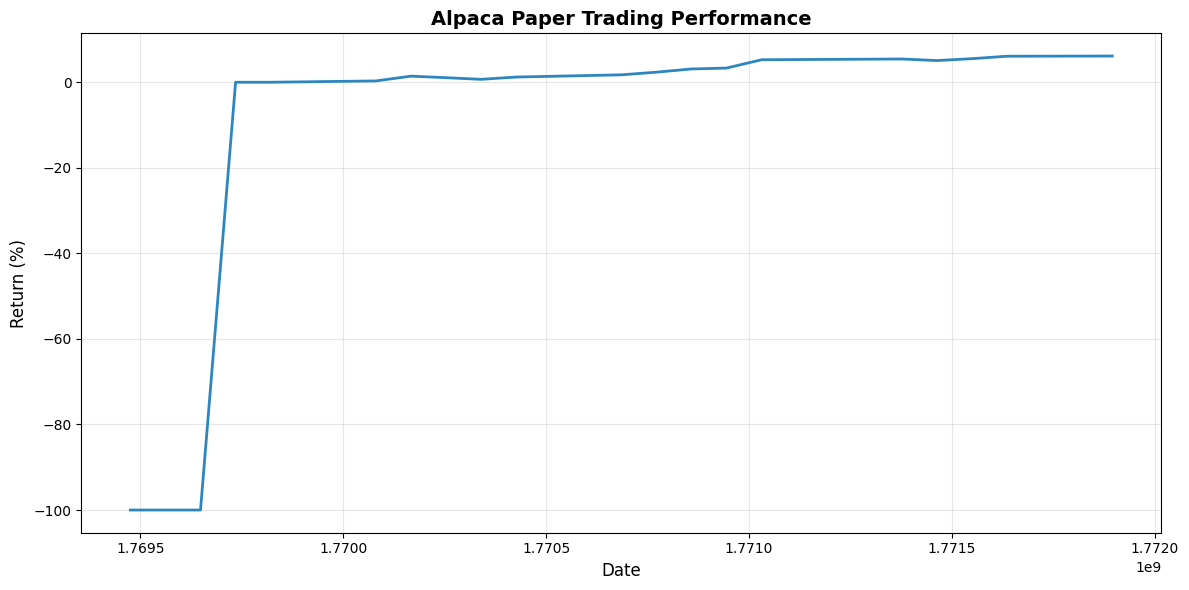

{'initial': 100000.0, 'final': 106126.56, 'return': 0.061265599999999976}

In [7]:
get_performance_history(
    api_key= os.getenv('ALPACA_API_KEY'),
    secret_key= os.getenv('ALPACA_SECRET_KEY')
)

In [8]:
# Live Paper Account Progress + Risk Metrics

from scipy import stats

# NOTE: Uses Alpaca paper account history to summarize current progress and risk metrics.

def _portfolio_history_df(api_key, secret_key, period='3M', timeframe='1D'):
    alpaca = AlpacaPaperTrading(api_key=api_key, secret_key=secret_key)
    ph = alpaca.api.get_portfolio_history(period=period, timeframe=timeframe)

    equity = np.array(ph.equity)
    timestamps = getattr(ph, 'timestamp', None)
    if timestamps is None:
        idx = pd.RangeIndex(len(equity))
    else:
        idx = pd.to_datetime(pd.Series(timestamps), unit='s')

    df = pd.DataFrame({'equity': equity}, index=idx).sort_index()
    df['returns'] = df['equity'].pct_change()
    df = df.dropna()
    return df, alpaca


def _risk_metrics(returns, risk_free_rate=0.045, periods_per_year=252):
    returns = np.asarray(returns)
    if len(returns) < 2:
        raise ValueError("Need at least 2 return observations")

    avg_period_return = returns.mean()
    vol_period = returns.std(ddof=1)

    annual_return = avg_period_return * periods_per_year
    annual_vol = vol_period * np.sqrt(periods_per_year)

    sharpe = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else 0.0

    downside = returns[returns < 0]
    downside_vol = downside.std(ddof=1) * np.sqrt(periods_per_year) if len(downside) > 0 else 0.0
    sortino = (annual_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0.0

    cumulative = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    calmar = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0.0
    win_rate = (returns > 0).mean()

    return {
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_drawdown,
        'calmar': calmar,
        'win_rate': win_rate,
        'observations': len(returns),
    }


def live_account_progress(api_key, secret_key, period='3M', timeframe='1D', risk_free_rate=0.045):
    df, alpaca = _portfolio_history_df(api_key, secret_key, period=period, timeframe=timeframe)
    if df.empty:
        print("No portfolio history available yet.")
        return None, df

    account = alpaca.api.get_account()

    start_equity = df['equity'].iloc[0]
    end_equity = df['equity'].iloc[-1]
    period_return = (end_equity - start_equity) / start_equity if start_equity != 0 else 0.0

    print(f"\n{'='*70}")
    print("LIVE PAPER ACCOUNT PROGRESS")
    print(f"{'='*70}")
    print(f"Account Status: {account.status}")
    print(f"Equity (Now): ${float(account.equity):,.2f}")
    print(f"Cash: ${float(account.cash):,.2f}")
    print(f"Buying Power: ${float(account.buying_power):,.2f}")
    print(f"Period: {period} | Timeframe: {timeframe}")
    print(f"Period Return: {period_return:.2%}")
    print(f"Observations: {len(df)}")

    # Positions snapshot (top 10 by market value)
    try:
        positions = alpaca.api.list_positions()
        if positions:
            pos_rows = []
            for p in positions:
                try:
                    mv = float(p.market_value)
                except Exception:
                    mv = 0.0
                pos_rows.append((p.symbol, mv, float(p.qty)))
            pos_rows.sort(key=lambda x: x[1], reverse=True)

            print("\nTop Positions (by market value):")
            for sym, mv, qty in pos_rows[:10]:
                print(f"  {sym:<6} | Qty: {qty:<8.2f} | Mkt Value: ${mv:,.2f}")
        else:
            print("\nNo open positions.")
    except Exception as e:
        print(f"\nPosition snapshot unavailable: {e}")

    metrics = _risk_metrics(df['returns'], risk_free_rate=risk_free_rate)

    print(f"\n{'='*70}")
    print("RISK-ADJUSTED METRICS (LIVE)")
    print(f"{'='*70}")
    print(f"Annual Return: {metrics['annual_return']:.2%}")
    print(f"Annual Volatility: {metrics['annual_vol']:.2%}")
    print(f"Sharpe Ratio: {metrics['sharpe']:.3f}")
    print(f"Sortino Ratio: {metrics['sortino']:.3f}")
    print(f"Max Drawdown: {metrics['max_drawdown']:.2%}")
    print(f"Calmar Ratio: {metrics['calmar']:.3f}")
    print(f"Win Rate: {metrics['win_rate']:.2%}")

    return metrics, df


# Run live progress + metrics
live_metrics, live_df = live_account_progress(
    api_key=api_key,
    secret_key=secret_key,
    period='3M',
    timeframe='1D',
    risk_free_rate=0.045
)


✓ Connected to Alpaca Paper Trading



LIVE PAPER ACCOUNT PROGRESS
Account Status: ACTIVE
Equity (Now): $106,678.08
Cash: $5,443.09
Buying Power: $294,861.49
Period: 3M | Timeframe: 1D
Period Return: 6.13%
Observations: 17

Top Positions (by market value):
  SPY    | Qty: 32.00    | Mkt Value: $22,002.56
  XLU    | Qty: 322.00   | Mkt Value: $15,174.25
  DUK    | Qty: 116.00   | Mkt Value: $14,875.84
  DTE    | Qty: 94.00    | Mkt Value: $13,724.00
  BIP    | Qty: 294.00   | Mkt Value: $11,510.10
  AEP    | Qty: 84.00    | Mkt Value: $11,102.49
  ICLN   | Qty: 289.00   | Mkt Value: $5,557.64
  GOOG   | Qty: 16.00    | Mkt Value: $4,979.20
  CAT    | Qty: 3.00     | Mkt Value: $2,309.07

RISK-ADJUSTED METRICS (LIVE)
Annual Return: inf%
Annual Volatility: nan%
Sharpe Ratio: 0.000
Sortino Ratio: inf
Max Drawdown: nan%
Calmar Ratio: nan
Win Rate: 76.47%


/Users/lewis/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/var/folders/np/35rvmxqn34z0tw1r9rdvqzbr0000gn/T/ipykernel_99595/1625851788.py:43: RuntimeWarning: invalid value encountered in subtract
  drawdown = (cumulative - running_max) / running_max


In [9]:
# Live Statistical Significance Tests (Strategy vs SPY)

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from scipy import stats


def _get_live_df(api_key, secret_key, period='3M', timeframe='1D'):
    if 'live_df' in globals() and isinstance(live_df, pd.DataFrame) and not live_df.empty:
        return live_df.copy()
    if '_portfolio_history_df' in globals():
        df, _ = _portfolio_history_df(api_key, secret_key, period=period, timeframe=timeframe)
        return df
    if 'AlpacaPaperTrading' in globals():
        alpaca = AlpacaPaperTrading(api_key=api_key, secret_key=secret_key)
        ph = alpaca.api.get_portfolio_history(period=period, timeframe=timeframe)
        equity = np.array(ph.equity)
        timestamps = getattr(ph, 'timestamp', None)
        if timestamps is None:
            idx = pd.RangeIndex(len(equity))
        else:
            idx = pd.to_datetime(pd.Series(timestamps), unit='s')
        df = pd.DataFrame({'equity': equity}, index=idx).sort_index()
        df['returns'] = df['equity'].pct_change()
        return df.dropna()
    return pd.DataFrame()


def run_live_stat_tests(api_key, secret_key, period='3M', timeframe='1D', risk_free_rate=0.045, benchmark='SPY'):
    try:
        df = _get_live_df(api_key, secret_key, period=period, timeframe=timeframe)
    except Exception as e:
        print(f"Error getting live data: {e}")
        return None
    
    if df.empty or len(df) < 5:
        print("Not enough data to run significance tests.")
        return None

    # Ensure index is datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        print("Warning: DataFrame index is not DatetimeIndex, attempting conversion...")
        try:
            df.index = pd.to_datetime(df.index)
        except Exception as e:
            print(f"Failed to convert index: {e}")
            return None
    start_date = df.index.min().date()
    end_date = df.index.max().date()

    bench = yf.download(benchmark, start=start_date, end=end_date + timedelta(days=1), progress=False)
    if bench.empty:
        print("Benchmark data unavailable.")
        return None

    # Normalize benchmark to a Series of returns
    if isinstance(bench.columns, pd.MultiIndex):
        if 'Adj Close' in bench.columns.get_level_values(0):
            bench = bench.xs('Adj Close', level=0, axis=1)
        elif 'Close' in bench.columns.get_level_values(0):
            bench = bench.xs('Close', level=0, axis=1)
    else:
        bench = bench['Adj Close'] if 'Adj Close' in bench.columns else bench['Close']

    if isinstance(bench, pd.DataFrame):
        if benchmark in bench.columns:
            bench = bench[benchmark]
        else:
            bench = bench.iloc[:, 0]

    bench = bench.rename('bench').pct_change().dropna()

    aligned = pd.DataFrame({'strategy': df['returns']}).join(bench, how='inner').dropna()
    if len(aligned) < 5:
        print("Not enough overlapping data with benchmark.")
        return None

    strategy_r = aligned['strategy'].values
    bench_r = aligned['bench'].values
    excess_r = strategy_r - bench_r

    print(f"\n{'='*70}")
    print("LIVE STATISTICAL SIGNIFICANCE TESTS")
    print(f"{'='*70}")
    print(f"Benchmark: {benchmark}")
    print(f"Samples: {len(aligned)}")
    print(f"Date Range: {aligned.index.min().date()} → {aligned.index.max().date()}")

    t_stat, p_val = stats.ttest_1samp(excess_r, popmean=0.0)
    print("\nOne-sample t-test (Excess returns vs 0):")
    print(f"  t-stat: {t_stat:.3f}")
    print(f"  p-value: {p_val:.4f}")

    t_stat2, p_val2 = stats.ttest_rel(strategy_r, bench_r)
    print("\nPaired t-test (Strategy vs Benchmark):")
    print(f"  t-stat: {t_stat2:.3f}")
    print(f"  p-value: {p_val2:.4f}")

    if excess_r.std(ddof=1) == 0:
        ir = 0.0
    else:
        ir = excess_r.mean() / excess_r.std(ddof=1) * np.sqrt(252)
    print("\nInformation Ratio:")
    print(f"  IR: {ir:.3f}")

    rng = np.random.default_rng(42)
    n_boot = 2000
    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(excess_r, size=len(excess_r), replace=True)
        boot_means.append(sample.mean())
    boot_means = np.array(boot_means)
    prob_pos = (boot_means > 0).mean()
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    print("\nBootstrap Alpha (Excess Return) Summary:")
    print(f"  P(alpha > 0): {prob_pos:.2%}")
    print(f"  95% CI: [{ci_low:.4%}, {ci_high:.4%}]")

    return {
        'p_value_excess': p_val,
        'p_value_pair': p_val2,
        'info_ratio': ir,
        'prob_alpha_pos': prob_pos,
        'boot_ci': (ci_low, ci_high),
        'samples': len(aligned),
    }


live_stats = run_live_stat_tests(
    api_key=api_key,
    secret_key=secret_key,
    period='3M',
    timeframe='1D',
    risk_free_rate=0.045,
    benchmark='SPY'
)


Not enough overlapping data with benchmark.


In [10]:
# 5-Year Backtest: Metrics + Statistical Significance

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from scipy import stats


def run_5year_backtest_with_stats(tickers, initial_capital=100000, risk_free_rate=0.045, train_window=252, test_window=63):
    """
    Walk-forward backtest (5Y) with metrics and statistical significance tests.
    """
    if not tickers or len(tickers) < 3:
        print("Provide at least 3 tickers for the backtest universe.")
        return None

    # De-duplicate while preserving order
    tickers = list(dict.fromkeys(tickers))

    print(f"\n{'='*70}")
    print("5-YEAR BACKTEST WITH STATISTICAL SIGNIFICANCE")
    print(f"{'='*70}")
    print(f"Universe: {len(tickers)} stocks")
    print(f"Initial Capital: ${initial_capital:,.0f}")

    end_date = datetime.now()
    start_date = end_date - timedelta(days=5*365 + 100)

    print(f"\nFetching data from {start_date.date()} to {end_date.date()}...")

    stock_data = yf.download(tickers, start=start_date, end=end_date, progress=False)
    if stock_data.empty:
        print("No stock data returned.")
        return None

    if isinstance(stock_data.columns, pd.MultiIndex):
        stock_data = stock_data['Adj Close'] if 'Adj Close' in stock_data.columns.get_level_values(0) else stock_data['Close']
    if isinstance(stock_data, pd.Series):
        stock_data = stock_data.to_frame()
    stock_data = stock_data.ffill().bfill()

    spy_raw = yf.download('SPY', start=start_date, end=end_date, progress=False)
    if spy_raw.empty:
        print("SPY data unavailable.")
        return None

    if isinstance(spy_raw.columns, pd.MultiIndex):
        if 'Adj Close' in spy_raw.columns.get_level_values(0):
            spy_series = spy_raw.xs('Adj Close', level=0, axis=1)
        elif 'Close' in spy_raw.columns.get_level_values(0):
            spy_series = spy_raw.xs('Close', level=0, axis=1)
        else:
            spy_series = spy_raw
    else:
        # Handle MultiIndex for SPY
        if isinstance(spy_raw.columns, pd.MultiIndex):
            spy_series = spy_raw['Adj Close'] if 'Adj Close' in spy_raw.columns.get_level_values(0) else spy_raw['Close']
        else:
            spy_series = spy_raw['Adj Close'] if 'Adj Close' in spy_raw.columns else spy_raw['Close']
        # Ensure it is a Series
        if isinstance(spy_series, pd.DataFrame):
            spy_series = spy_series.iloc[:, 0]

    if isinstance(spy_series, pd.DataFrame):
        if 'SPY' in spy_series.columns:
            spy_series = spy_series['SPY']
        else:
            spy_series = spy_series.iloc[:, 0]

    spy_series = spy_series.reindex(stock_data.index).ffill().bfill()

    print(f"✓ Downloaded {len(stock_data)} days of data")

    portfolio_values = [initial_capital]
    spy_values = [initial_capital]
    dates = []

    start_idx = train_window

    while start_idx + test_window <= len(stock_data):
        train_data = stock_data.iloc[start_idx - train_window:start_idx]
        train_returns = train_data.pct_change().dropna()

        if train_returns.empty:
            start_idx += test_window
            continue

        scores = {}
        for ticker in train_data.columns:
            try:
                prices = train_data[ticker]
                rets = train_returns[ticker]
                mom = 0.6 * prices.pct_change(63).iloc[-1] + 0.4 * prices.pct_change(126).iloc[-1]
                sharpe = (rets.mean() * 252) / (rets.std() * np.sqrt(252)) if rets.std() > 0 else 0.0
                value = 1 / (rets.std() * np.sqrt(252)) if rets.std() > 0 else 0.0
                scores[ticker] = 0.4 * mom + 0.3 * sharpe + 0.3 * value
            except Exception:
                scores[ticker] = -999

        top_tickers = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
        top_tickers = [t for t, _ in top_tickers]

        selected_returns = train_returns[top_tickers].iloc[-63:]
        if selected_returns.empty:
            start_idx += test_window
            continue

        variances = selected_returns.var().replace(0, np.nan).dropna()
        if variances.empty:
            start_idx += test_window
            continue

        weights = (1 / variances) / (1 / variances).sum()
        weights = np.clip(weights * 0.5, 0, 0.10)
        weights = weights / weights.sum()

        test_data = stock_data[top_tickers].iloc[start_idx:start_idx + test_window]
        test_returns = test_data.pct_change().dropna()
        if test_returns.empty:
            start_idx += test_window
            continue

        period_port = (1 + (test_returns @ weights)).prod() - 1
        portfolio_values.append(portfolio_values[-1] * (1 + period_port))

        spy_slice = spy_series.iloc[start_idx:start_idx + test_window].pct_change().dropna()
        period_spy = (1 + spy_slice).prod() - 1 if not spy_slice.empty else 0.0
        if isinstance(period_spy, (pd.Series, pd.DataFrame)):
            period_spy = float(period_spy.iloc[0]) if not period_spy.empty else 0.0
        else:
            period_spy = float(period_spy)
        spy_values.append(float(spy_values[-1] * (1 + period_spy)))

        dates.append(stock_data.index[start_idx + test_window - 1])
        start_idx += test_window

    if len(portfolio_values) < 3:
        print("Not enough backtest periods to compute statistics.")
        return None

    portfolio_returns = np.diff(portfolio_values) / portfolio_values[:-1]
    spy_returns = np.diff(spy_values) / spy_values[:-1]

    print(f"\n{'='*70}")
    print("BACKTEST RESULTS")
    print(f"{'='*70}")

    port_total = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0]
    spy_total = (spy_values[-1] - spy_values[0]) / spy_values[0]

    # Calculate years based on actual test duration
    years = len(portfolio_returns) * (test_window / 252)
    if years == 0: years = 1e-6
    port_cagr = (portfolio_values[-1] / portfolio_values[0]) ** (1/years) - 1
    spy_cagr = (spy_values[-1] / spy_values[0]) ** (1/years) - 1

    port_vol = np.std(portfolio_returns, ddof=1) * np.sqrt(252/test_window)
    spy_vol = np.std(spy_returns, ddof=1) * np.sqrt(252/test_window)

    port_sharpe = (port_cagr - risk_free_rate) / port_vol if port_vol > 0 else 0.0
    spy_sharpe = (spy_cagr - risk_free_rate) / spy_vol if spy_vol > 0 else 0.0

    cumulative = np.array(portfolio_values) / portfolio_values[0]
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    downside = portfolio_returns[portfolio_returns < 0]
    downside_vol = downside.std(ddof=1) * np.sqrt(252/test_window) if len(downside) > 0 else 0.0
    sortino = (port_cagr - risk_free_rate) / downside_vol if downside_vol > 0 else 0.0

    calmar = port_cagr / abs(max_drawdown) if max_drawdown != 0 else 0.0
    win_rate = (portfolio_returns > 0).mean()

    print("\nStrategy Performance:")
    print(f"  Total Return: {port_total:.2%}")
    print(f"  CAGR: {port_cagr:.2%}")
    print(f"  Volatility: {port_vol:.2%}")
    print(f"  Sharpe Ratio: {port_sharpe:.3f}")
    print(f"  Sortino Ratio: {sortino:.3f}")
    print(f"  Max Drawdown: {max_drawdown:.2%}")
    print(f"  Calmar Ratio: {calmar:.3f}")
    print(f"  Win Rate: {win_rate:.2%}")

    print("\nSPY Benchmark:")
    print(f"  Total Return: {spy_total:.2%}")
    print(f"  CAGR: {spy_cagr:.2%}")
    print(f"  Volatility: {spy_vol:.2%}")
    print(f"  Sharpe Ratio: {spy_sharpe:.3f}")

    print("\nOutperformance:")
    print(f"  Alpha: {port_cagr - spy_cagr:+.2%}")
    print(f"  Sharpe Diff: {port_sharpe - spy_sharpe:+.3f}")

    print(f"\n{'='*70}")
    print("STATISTICAL SIGNIFICANCE TESTS")
    print(f"{'='*70}")

    if len(portfolio_returns) != len(spy_returns) or len(portfolio_returns) < 2:
        print("Not enough aligned backtest returns for statistical tests.")
        return None

    t_stat, p_value = stats.ttest_rel(portfolio_returns, spy_returns)
    print("\nPaired t-test (Strategy vs SPY):")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_value:.4f}")

    n = len(portfolio_returns)
    sharpe_diff = port_sharpe - spy_sharpe
    se_diff = np.sqrt((1 + 0.5 * port_sharpe**2) / n + (1 + 0.5 * spy_sharpe**2) / n)
    z_score = sharpe_diff / se_diff if se_diff > 0 else 0.0
    p_sharpe = 2 * (1 - stats.norm.cdf(abs(z_score)))

    print("\nSharpe Ratio Difference Test:")
    print(f"  Sharpe Difference: {sharpe_diff:+.3f}")
    print(f"  z-score: {z_score:.3f}")
    print(f"  p-value: {p_sharpe:.4f}")

    excess_returns = portfolio_returns - spy_returns
    rng = np.random.default_rng(42)
    n_boot = 3000
    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(excess_returns, size=len(excess_returns), replace=True)
        boot_means.append(sample.mean())
    boot_means = np.array(boot_means)
    prob_pos = (boot_means > 0).mean()
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    print("\nBootstrap Alpha Summary:")
    print(f"  P(alpha > 0): {prob_pos:.2%}")
    print(f"  95% CI: [{ci_low:.4%}, {ci_high:.4%}]")

    return {
        'strategy_cagr': port_cagr,
        'spy_cagr': spy_cagr,
        'alpha': port_cagr - spy_cagr,
        'strategy_sharpe': port_sharpe,
        'spy_sharpe': spy_sharpe,
        'p_value_returns': p_value,
        'p_value_sharpe': p_sharpe,
        'prob_alpha_pos': prob_pos,
        'win_rate': win_rate,
    }


_default_universe = ['AAPL','MSFT','GOOGL','AMZN','NVDA','META','JPM','XOM','JNJ','UNH']
try:
    tickers
except NameError:
    tickers = _default_universe

backtest_results = run_5year_backtest_with_stats(tickers)



5-YEAR BACKTEST WITH STATISTICAL SIGNIFICANCE
Universe: 10 stocks
Initial Capital: $100,000

Fetching data from 2020-11-17 to 2026-02-24...


✓ Downloaded 1321 days of data

BACKTEST RESULTS

Strategy Performance:
  Total Return: 61.25%
  CAGR: 12.69%
  Volatility: 10.85%
  Sharpe Ratio: 0.754
  Sortino Ratio: 1.677
  Max Drawdown: -6.43%
  Calmar Ratio: 1.974
  Win Rate: 68.75%

SPY Benchmark:
  Total Return: 53.35%
  CAGR: 11.28%
  Volatility: 11.64%
  Sharpe Ratio: 0.583

Outperformance:
  Alpha: +1.41%
  Sharpe Diff: +0.172

STATISTICAL SIGNIFICANCE TESTS

Paired t-test (Strategy vs SPY):
  t-statistic: 0.291
  p-value: 0.7749

Sharpe Ratio Difference Test:
  Sharpe Difference: +0.172
  z-score: 0.438
  p-value: 0.6611

Bootstrap Alpha Summary:
  P(alpha > 0): 60.07%
  95% CI: [-1.4862%, 2.3489%]
